## Customer Churn Dataset

The dataset contains customer information from a telecommunications company. The main goal is to predict whether a customer will leave the company (`Churn`) based on their demographic information, services, contract details, and payment methods.

### Target Variable

* **Churn**

  * `Yes` → The customer left the company.
  * `No` → The customer remained with the company.

### Feature Types

The dataset contains two main types of features:

**Categorical Features**

* Gender
* Partner
* Dependents
* PhoneService
* MultipleLines
* InternetService
* OnlineSecurity
* OnlineBackup
* DeviceProtection
* TechSupport
* StreamingTV
* StreamingMovies
* Contract
* PaperlessBilling
* PaymentMethod

**Numerical Features**

* Tenure
* MonthlyCharges
* TotalCharges

### Main EDA Findings

The analysis showed that some features have a strong relationship with customer churn, while others show only a weak relationship.

#### Features with strong relationships with Churn

* **Contract:** Customers with month-to-month contracts have a much higher churn rate than customers with one-year or two-year contracts.
* **InternetService:** Fiber optic customers have a noticeably higher churn rate.
* **PaymentMethod:** Customers using electronic checks have a high churn rate compared with other payment methods.
* **TechSupport:** Customers without technical support have a higher churn rate.
* **OnlineSecurity:** Customers without online security have a higher churn rate.
* **OnlineBackup:** Customers without online backup have a higher churn rate.
* **DeviceProtection:** Customers without device protection have a higher churn rate.
* **Tenure:** Customers with shorter tenure tend to have a higher churn rate, while long-term customers are less likely to churn.
* **Partner and Dependents:** Customers without a partner or dependents tend to have higher churn rates.
* **PaperlessBilling:** Customers using paperless billing show a higher churn rate.

#### Features with weak relationships

* **Gender:** The churn rates for females and males are very similar.
* **PhoneService:** The difference in churn rate between customers with and without phone service is relatively small.
* **MultipleLines:** The difference between its categories is relatively small compared with stronger features.

### Important Note

The EDA findings describe relationships and patterns in the dataset. They do not prove that a feature directly causes customer churn.

Features with weak relationships should not automatically be removed before model training. Their actual usefulness can be evaluated later using model performance and feature-importance techniques.

### Numerical Data Analysis

The numerical features were analyzed using:

* Distribution plots
* Q-Q plots
* Boxplots
* Comparison with the Churn target

This helped identify the distribution shape, possible skewness, and potential outliers in the numerical variables.

### Conclusion

The EDA indicates that **Contract, Tenure, InternetService, PaymentMethod, TechSupport, OnlineSecurity, OnlineBackup, and DeviceProtection** are among the most informative features for predicting customer churn.

The next stage is **Data Preprocessing**, where the data will be cleaned and transformed into a suitable format for machine learning models.


In [12]:
import pandas as pd
import os

# path = r"C:\Users\C.M\Downloads\customer_churn_prediction"

data = pd.read_csv(r"C:\Users\C.M\Downloads\customer_churn_prediction\WA_Fn-UseC_-Telco-Customer-Churn.csv")
   


In [13]:
def info_data(data):
  print('Dataset shape:\n')
  print(data.shape)
  print('-'*30)
  print('Dataset columns:\n')
  print(data.columns)
  print('-'*30)
  print('Dataset Information:\n\n ')
  print( data.info())
  print('-'*30)
  print('Dataset Describe:\n')
  print(data.describe())
  print('-'*30)
  print('Type of columns:\n')
  print(data.dtypes)






In [14]:
info_data(data)

Dataset shape:

(7043, 21)
------------------------------
Dataset columns:

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
------------------------------
Dataset Information:

 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   

In [15]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
# Remove [customerID]
data.drop('customerID',axis=1,inplace=True)

In [17]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# Missing values
data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Feature Types

The dataset contains two main types of features:

**Categorical Features**

* Gender
* Partner
* Dependents
* PhoneService
* MultipleLines
* InternetService
* OnlineSecurity
* OnlineBackup
* DeviceProtection
* TechSupport
* StreamingTV
* StreamingMovies
* Contract
* PaperlessBilling
* PaymentMethod

**Numerical Features**

* Tenure
* MonthlyCharges
* TotalCharges

### Main EDA Findings

The analysis showed that some features have a strong relationship with customer churn, while others show only a weak relationship.


In [19]:
categorical_features = data.select_dtypes(include="object").columns.drop('Churn')
numerical_features = data.select_dtypes(include="number").columns

In [20]:
print('categorical_features:\n',list(categorical_features))
print("-"*30)
print('numerical_features:\n',list(numerical_features))

categorical_features:
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']
------------------------------
numerical_features:
 ['SeniorCitizen', 'tenure', 'MonthlyCharges']


## ***`EDA`***


### Important Note

The EDA findings describe relationships and patterns in the dataset. They do not prove that a feature directly causes customer churn.

Features with weak relationships should not automatically be removed before model training. Their actual usefulness can be evaluated later using model performance and feature-importance techniques.



In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Features with strong relationships with Churn

* **Contract:** Customers with month-to-month contracts have a much higher churn rate than customers with one-year or two-year contracts.
* **InternetService:** Fiber optic customers have a noticeably higher churn rate.
* **PaymentMethod:** Customers using electronic checks have a high churn rate compared with other payment methods.
* **TechSupport:** Customers without technical support have a higher churn rate.
* **OnlineSecurity:** Customers without online security have a higher churn rate.
* **OnlineBackup:** Customers without online backup have a higher churn rate.
* **DeviceProtection:** Customers without device protection have a higher churn rate.
* **Tenure:** Customers with shorter tenure tend to have a higher churn rate, while long-term customers are less likely to churn.
* **Partner and Dependents:** Customers without a partner or dependents tend to have higher churn rates.
* **PaperlessBilling:** Customers using paperless billing show a higher churn rate.

#### Features with weak relationships

* **Gender:** The churn rates for females and males are very similar.
* **PhoneService:** The difference in churn rate between customers with and without phone service is relatively small.
* **MultipleLines:** The difference between its categories is relatively small compared with stronger features.


In [ ]:
for feature in categorical_features:
  print("="*30)
  print(f'{feature} vs Churn')
  print("-"*30)
  result=pd.crosstab(data[feature],data['Churn'],normalize='index')*100
  print(result.round(2))



gender vs Churn
------------------------------
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16
Partner vs Churn
------------------------------
Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66
Dependents vs Churn
------------------------------
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45
PhoneService vs Churn
------------------------------
Churn            No    Yes
PhoneService              
No            75.07  24.93
Yes           73.29  26.71
MultipleLines vs Churn
------------------------------
Churn                No    Yes
MultipleLines                 
No                74.96  25.04
No phone service  75.07  24.93
Yes               71.39  28.61
InternetService vs Churn
------------------------------
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40
Online

In [ ]:
for feature2 in numerical_features:
  print('='*20)
  print(f'{feature2} vs Churn')
  print("-"*30)
  result2=pd.crosstab(data[feature2],data['Churn'],normalize='index')*100
  print(result2)

SeniorCitizen vs Churn
------------------------------
Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261
tenure vs Churn
------------------------------
Churn           No        Yes
tenure                       
0       100.000000   0.000000
1        38.009788  61.990212
2        48.319328  51.680672
3        53.000000  47.000000
4        52.840909  47.159091
...            ...        ...
68       91.000000   9.000000
69       91.578947   8.421053
70       90.756303   9.243697
71       96.470588   3.529412
72       98.342541   1.657459

[73 rows x 2 columns]
MonthlyCharges vs Churn
------------------------------
Churn              No    Yes
MonthlyCharges              
18.25           100.0    0.0
18.40           100.0    0.0
18.55           100.0    0.0
18.70           100.0    0.0
18.75           100.0    0.0
...               ...    ...
118.20          100.0    0.0
118.35            0.0  100

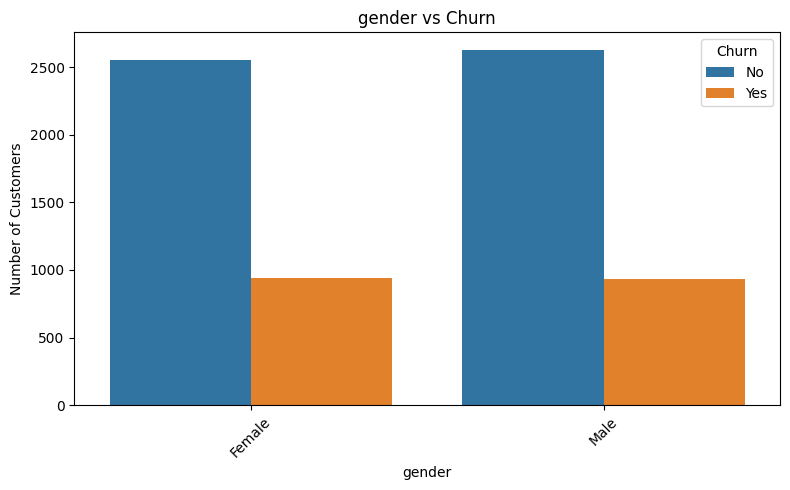

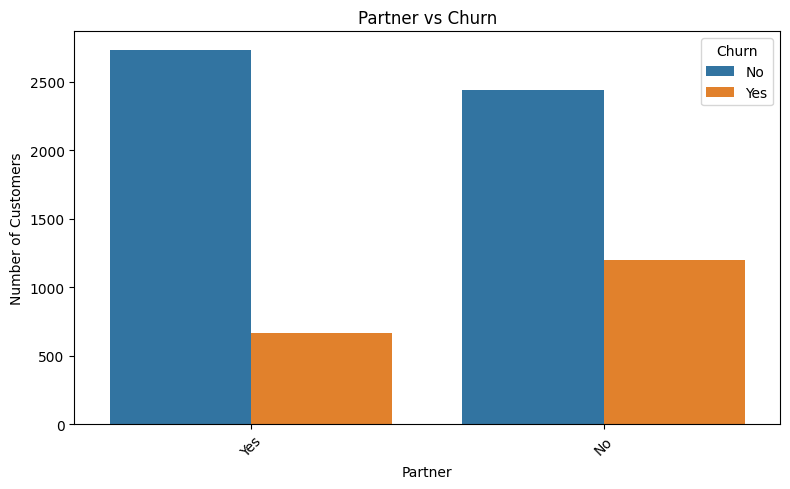

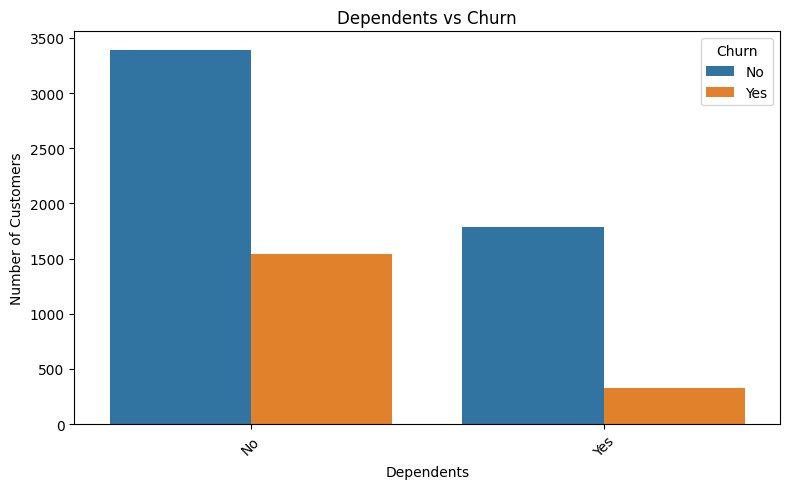

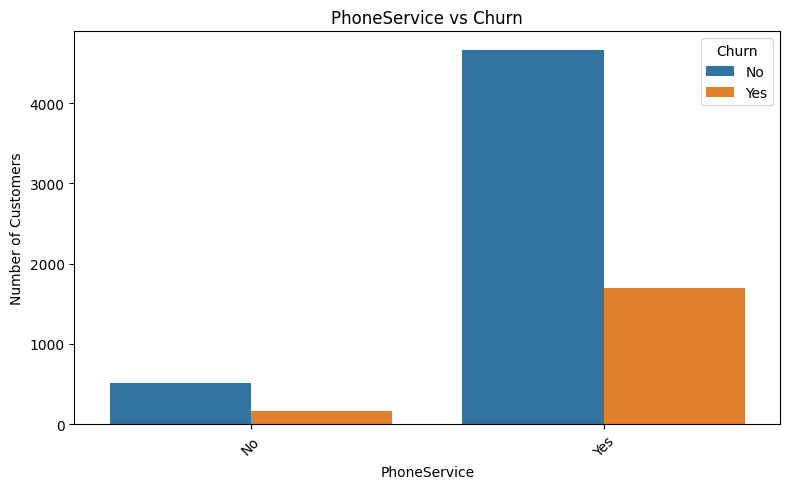

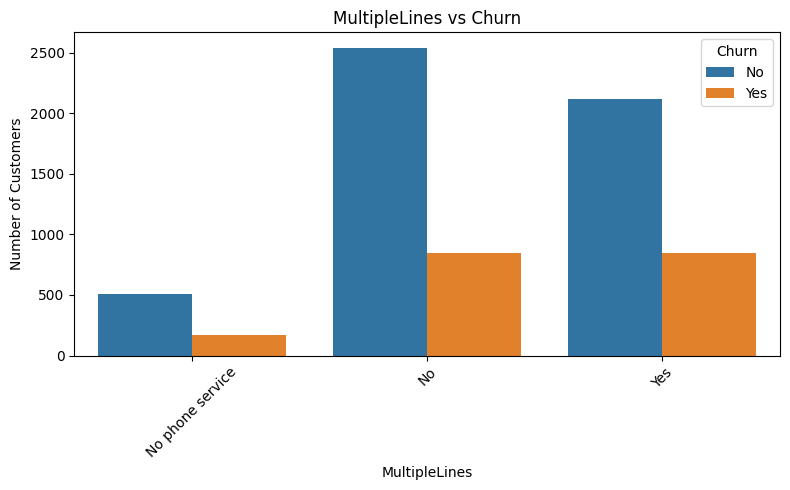

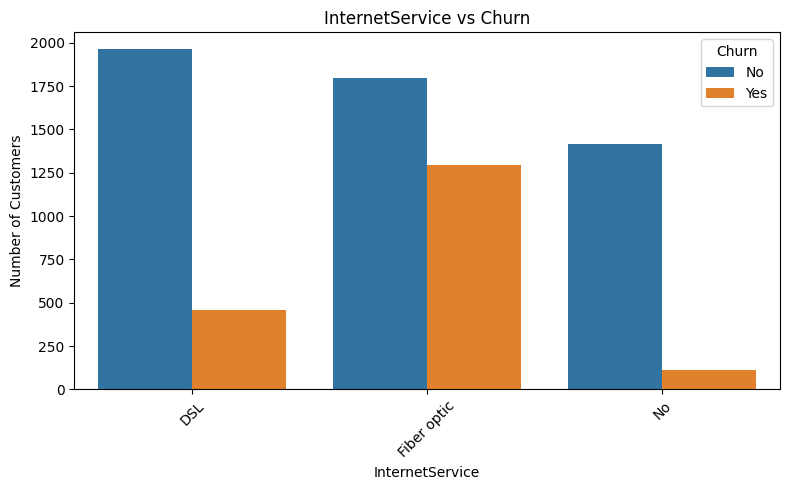

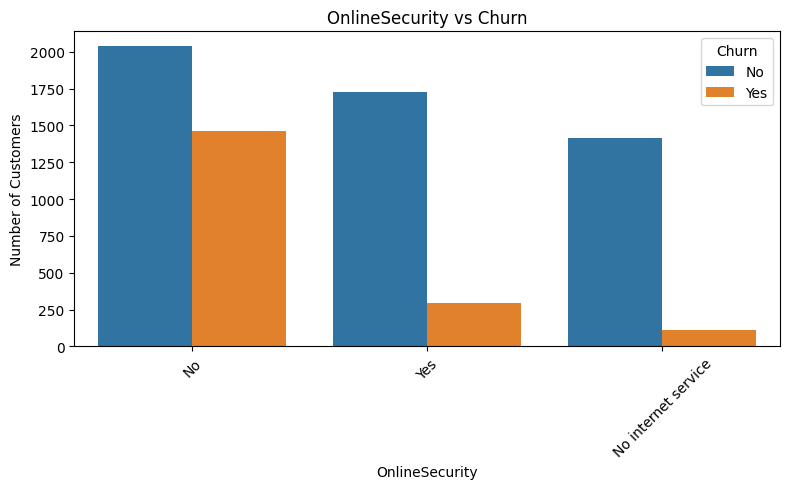

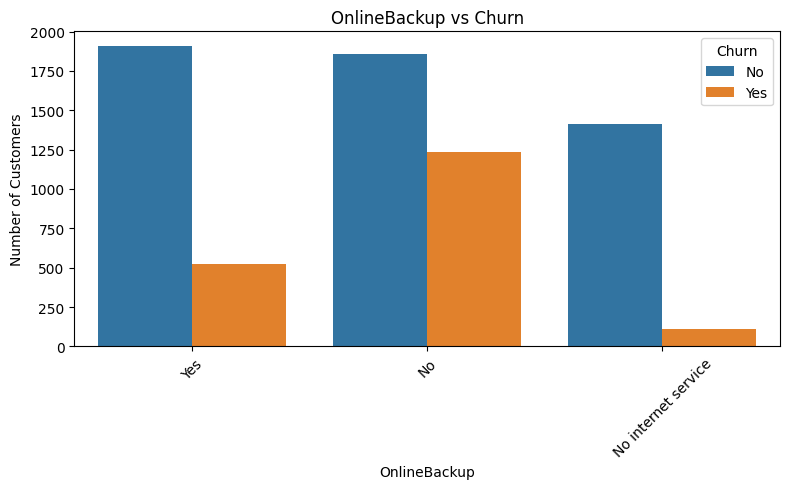

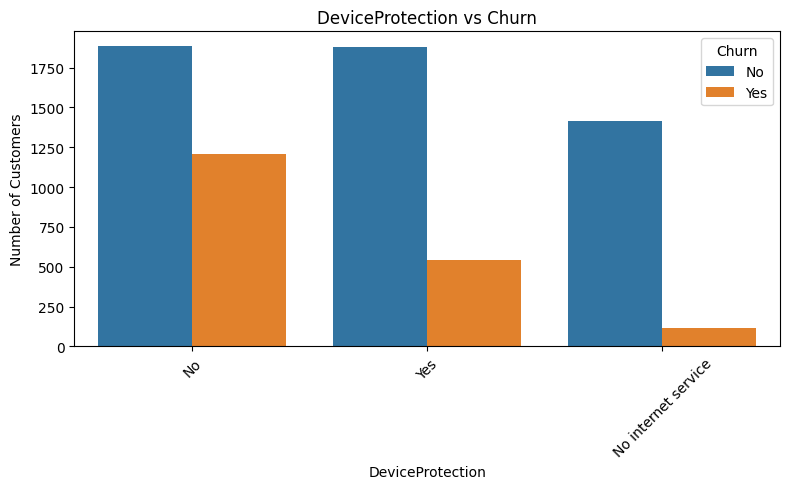

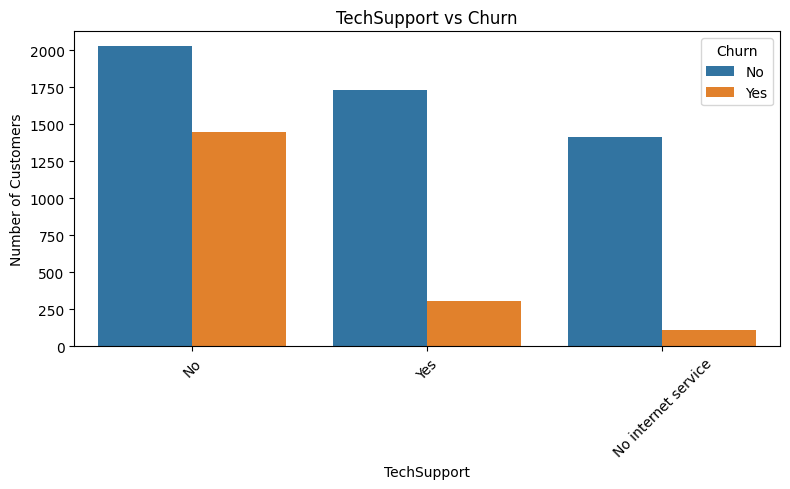

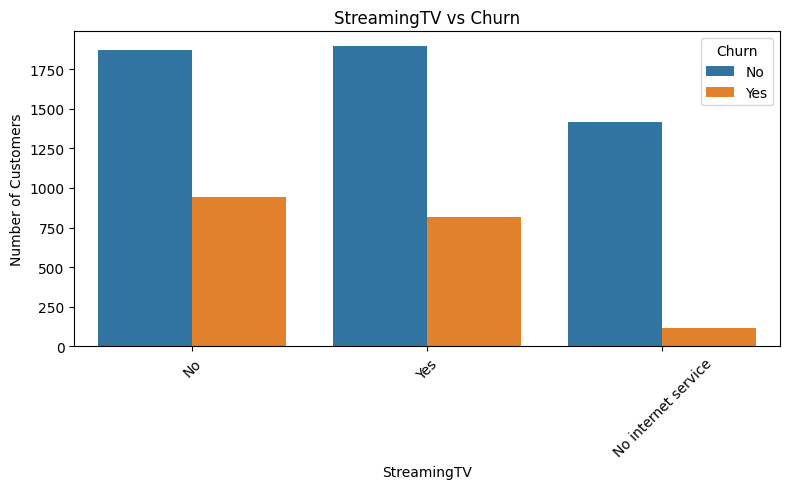

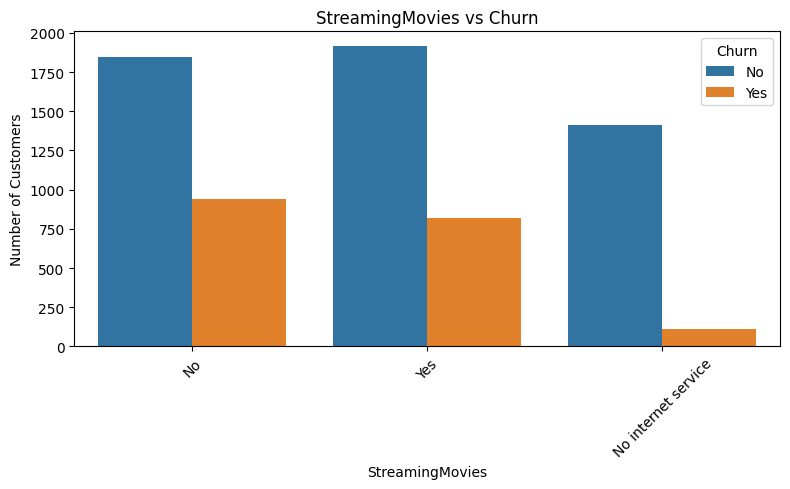

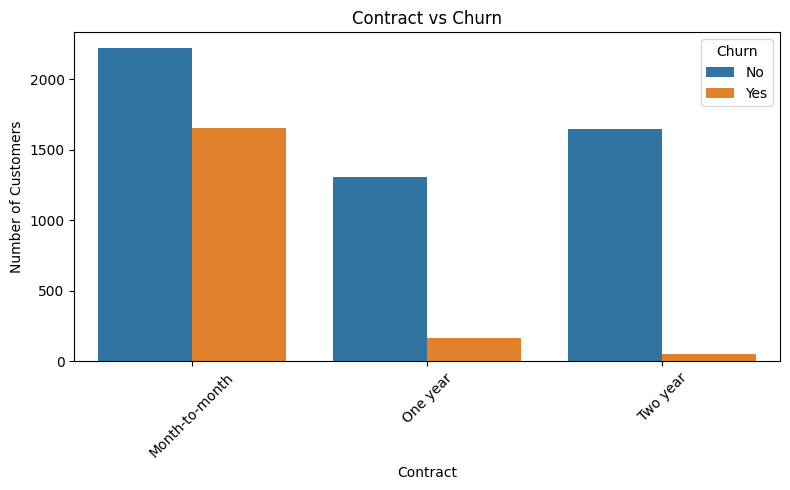

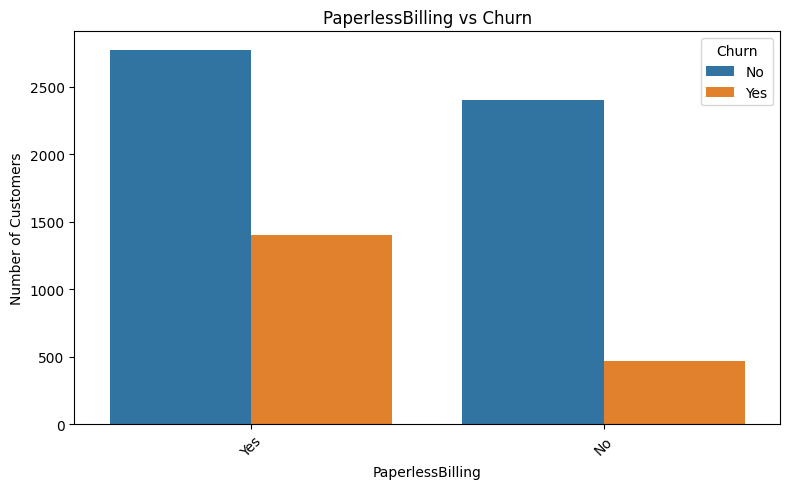

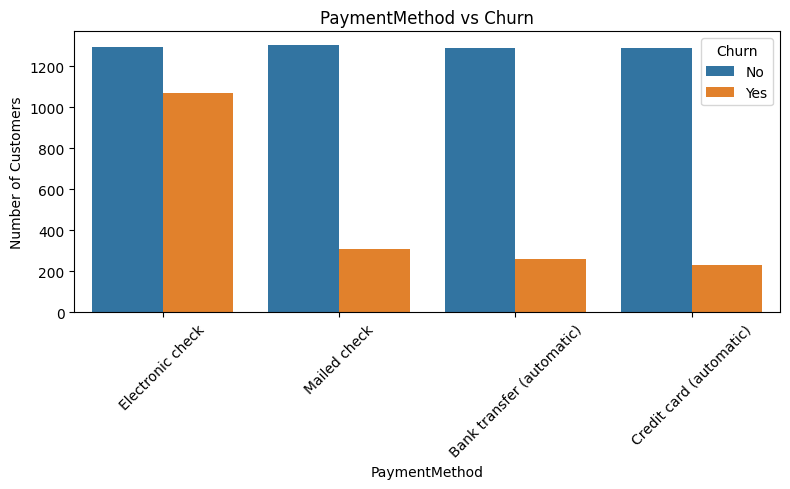

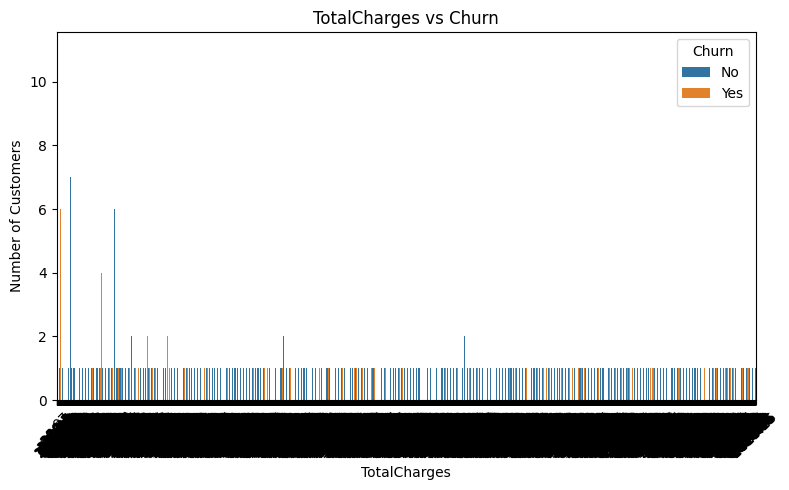

In [ ]:
for feature in categorical_features:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=data,
        x=feature,
        hue="Churn"
    )

    plt.title(f"{feature} vs Churn")
    plt.xlabel(feature)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

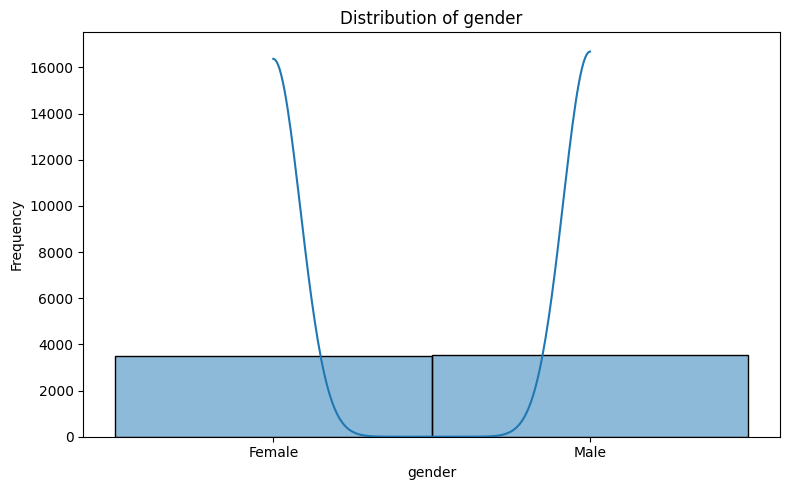

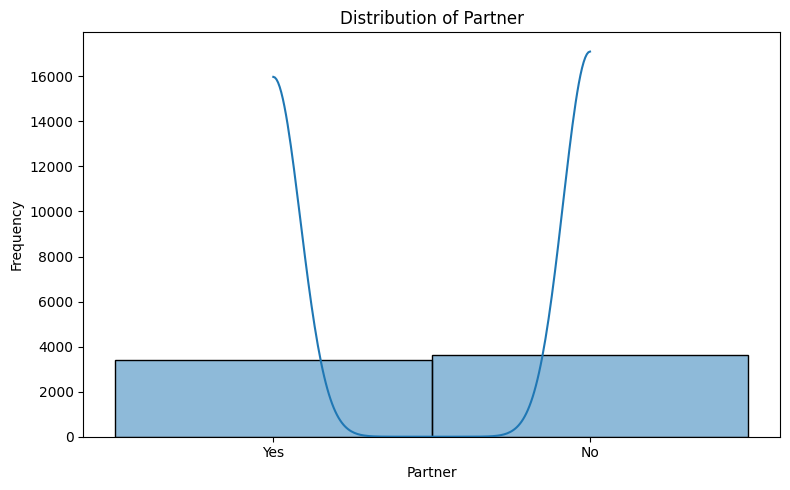

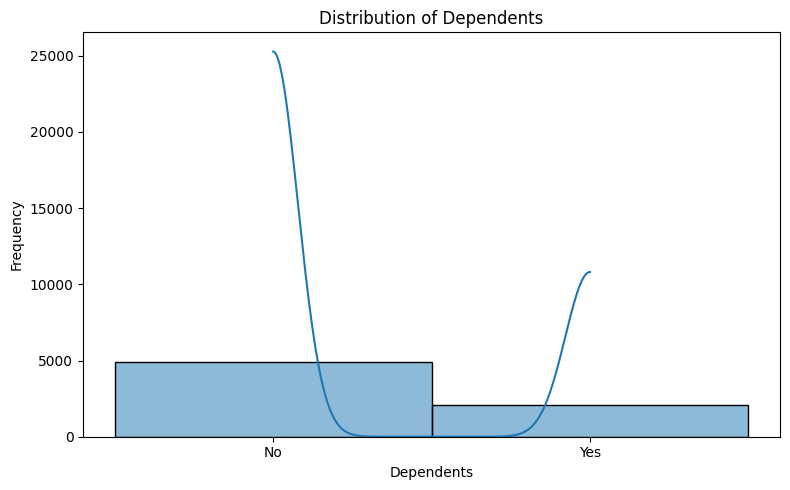

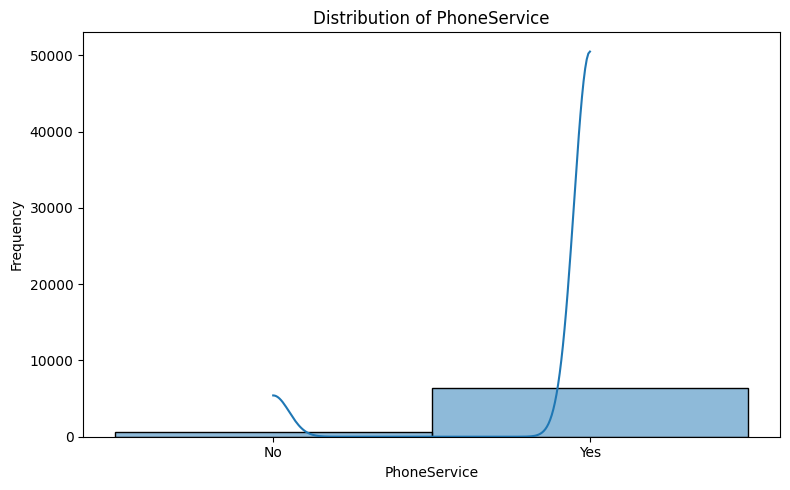

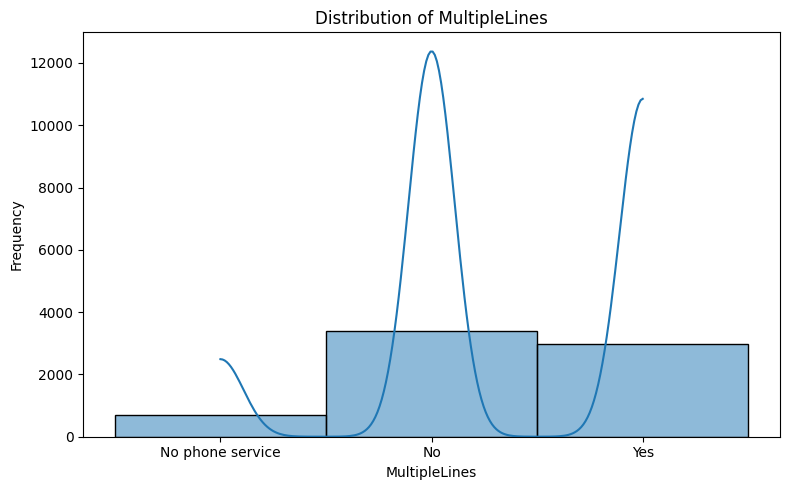

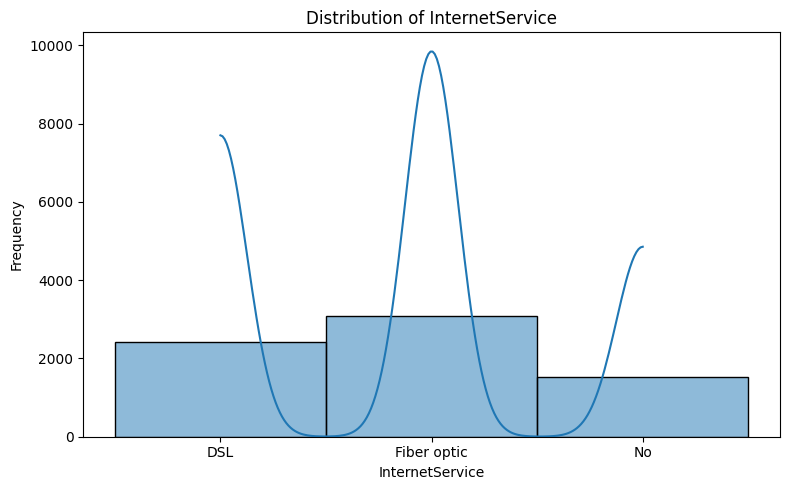

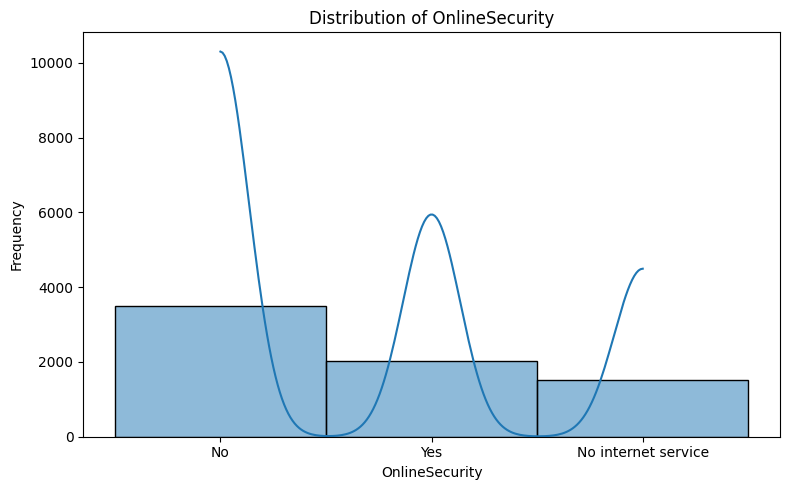

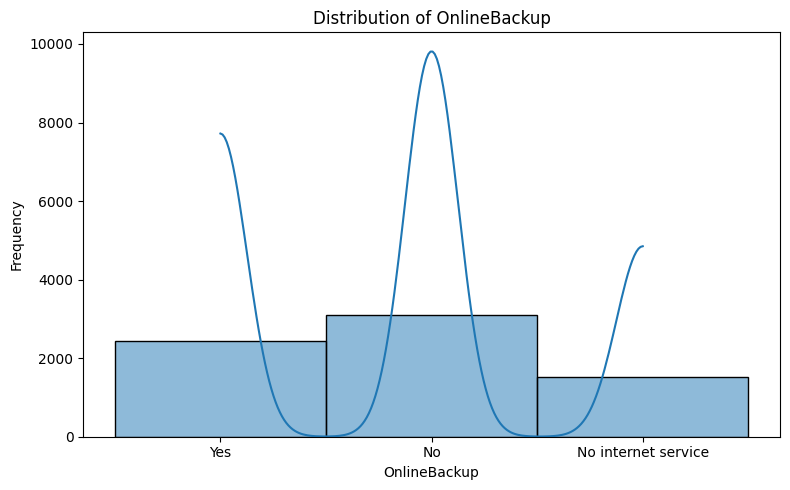

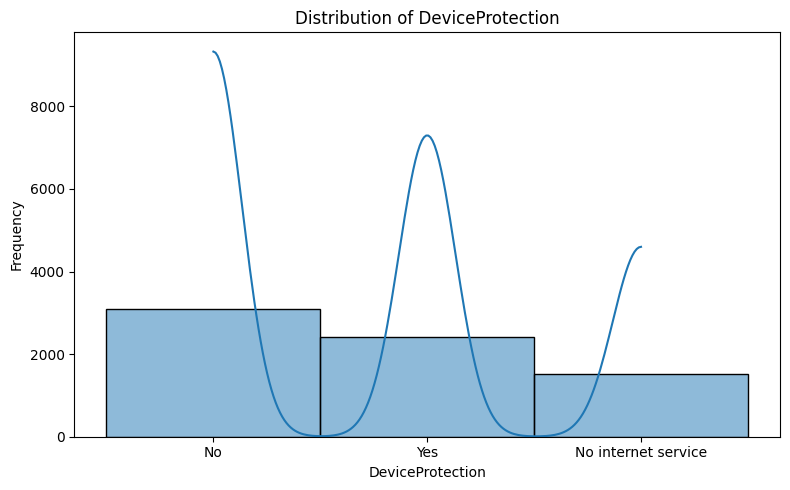

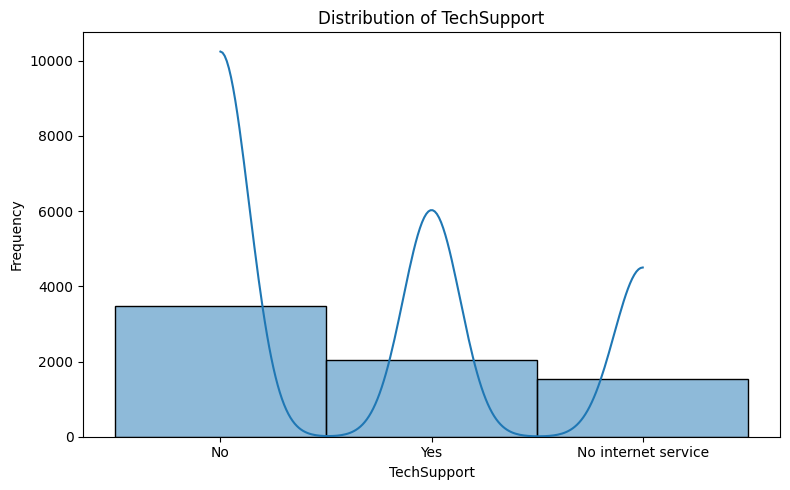

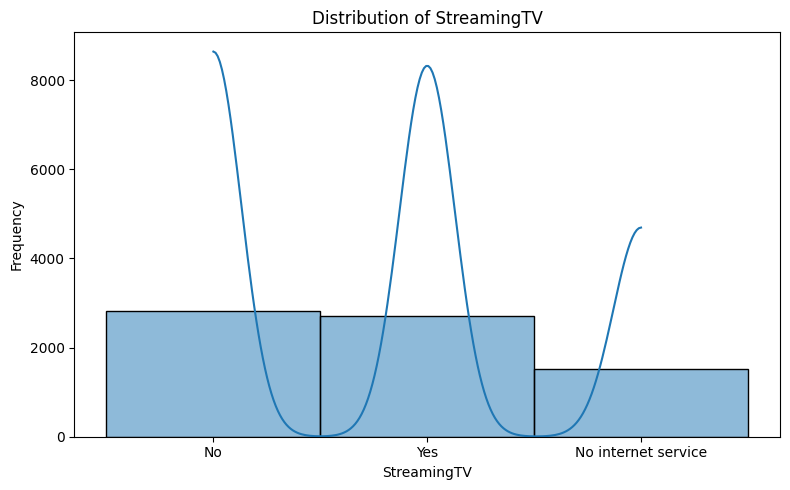

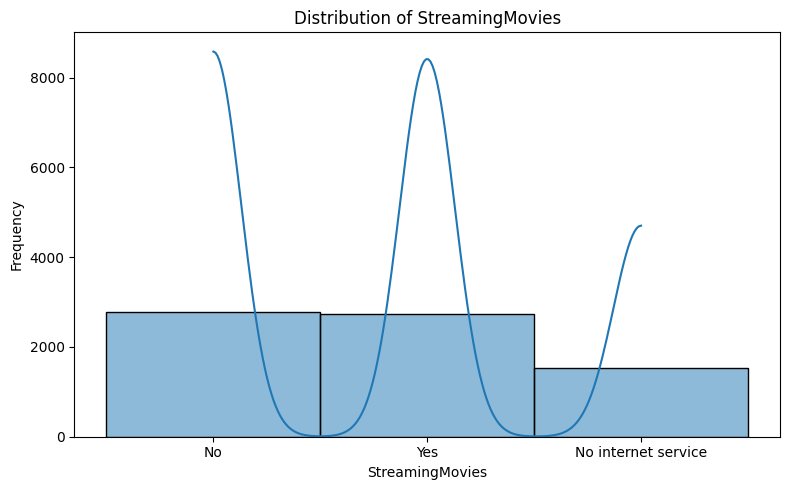

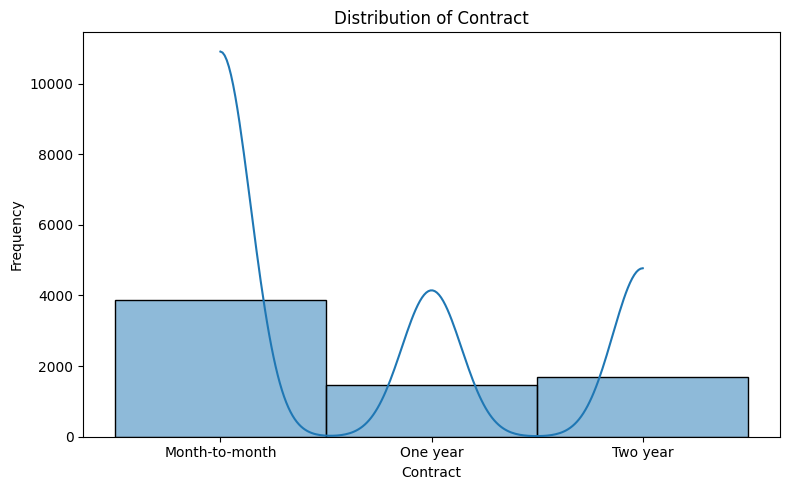

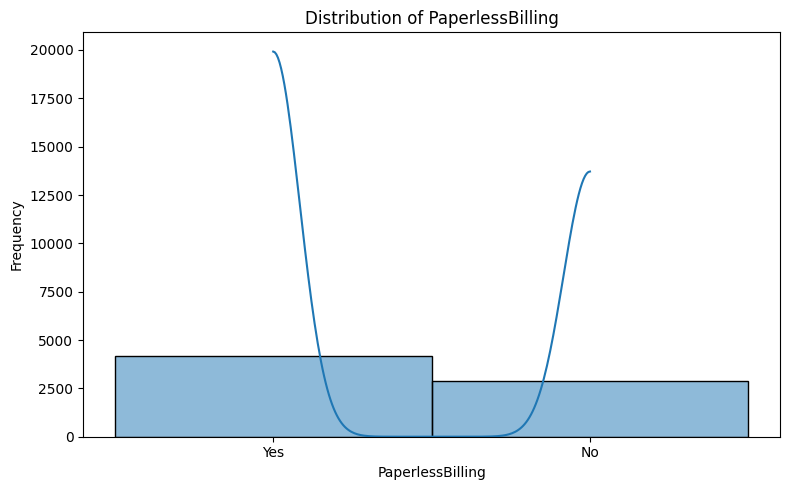

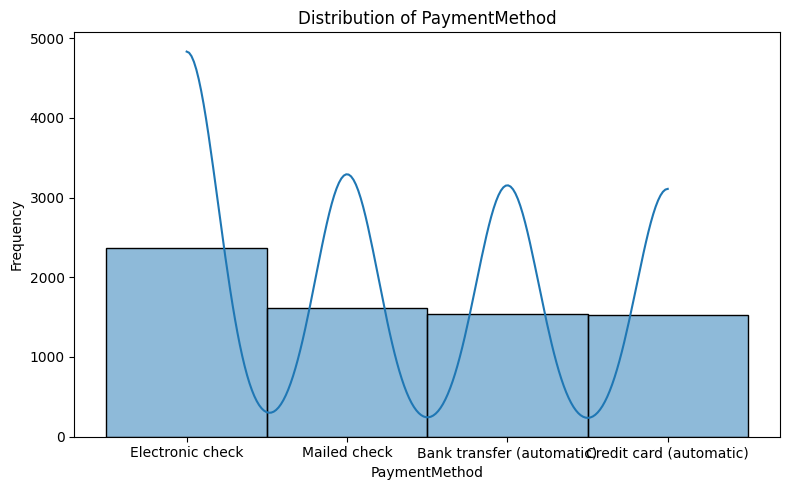

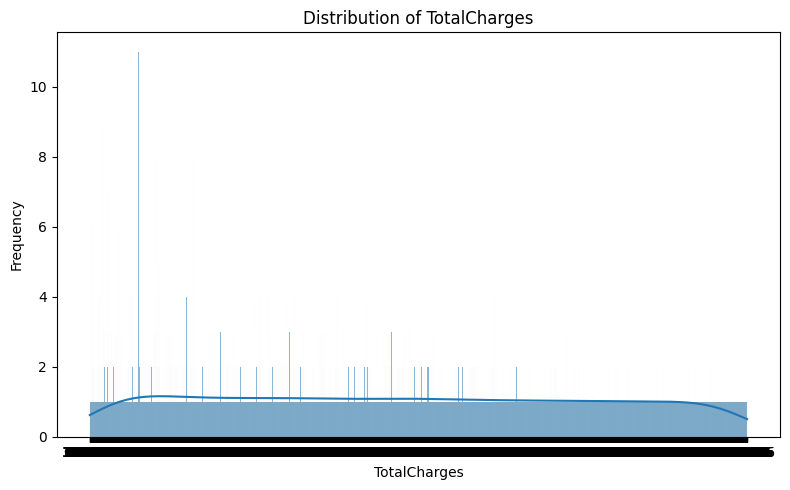

In [ ]:
for feature in categorical_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=data,
        x=feature,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

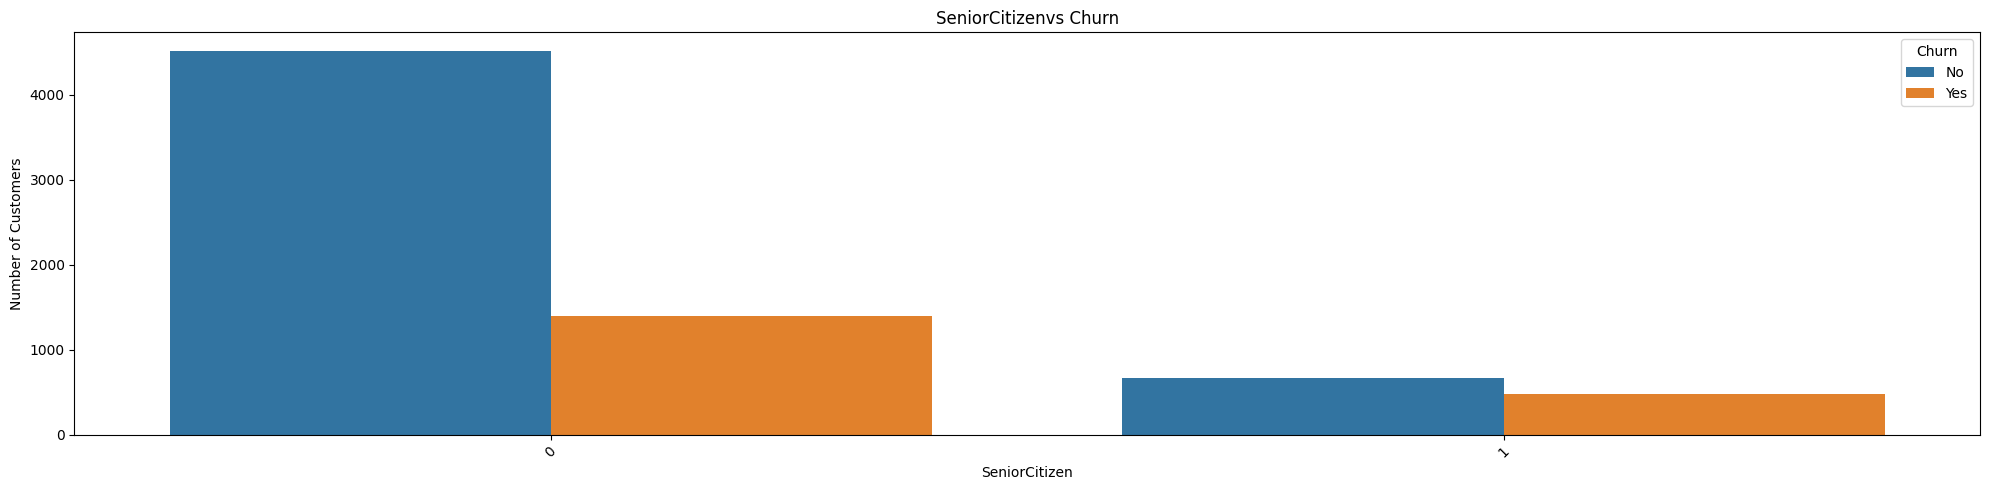

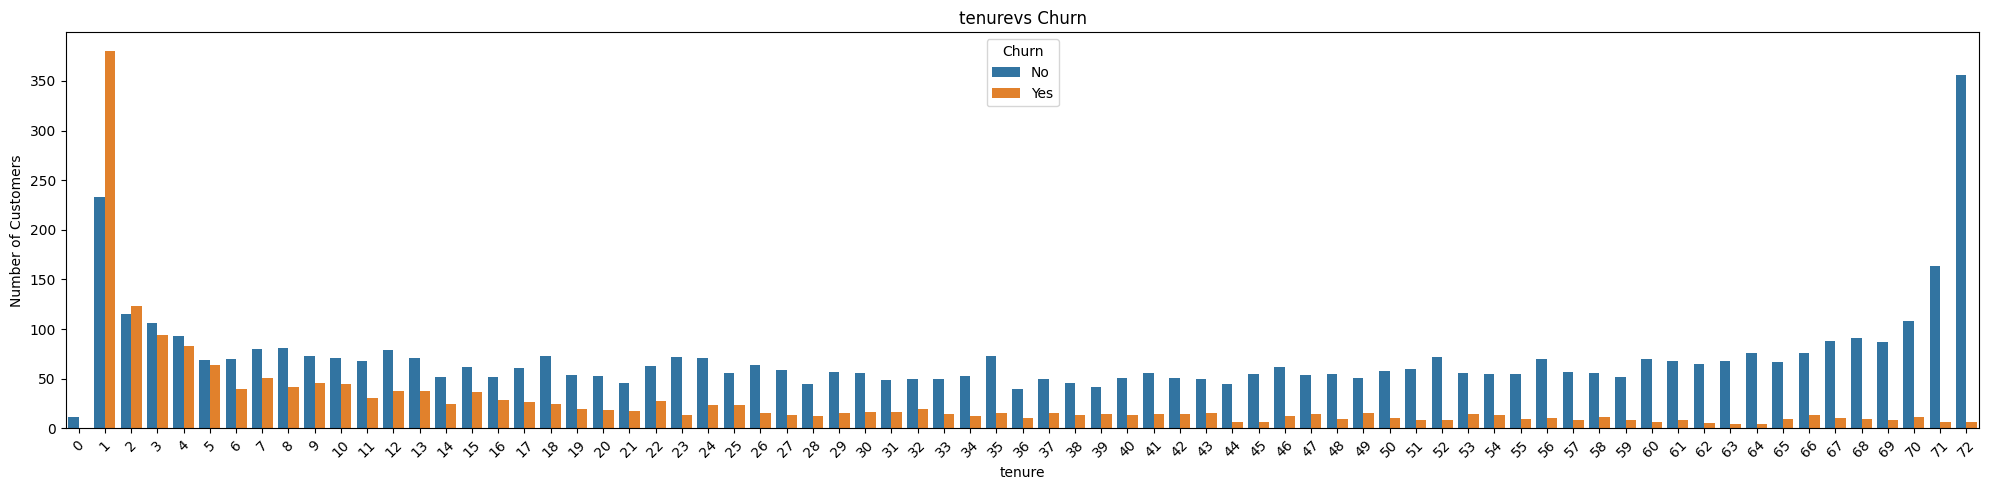

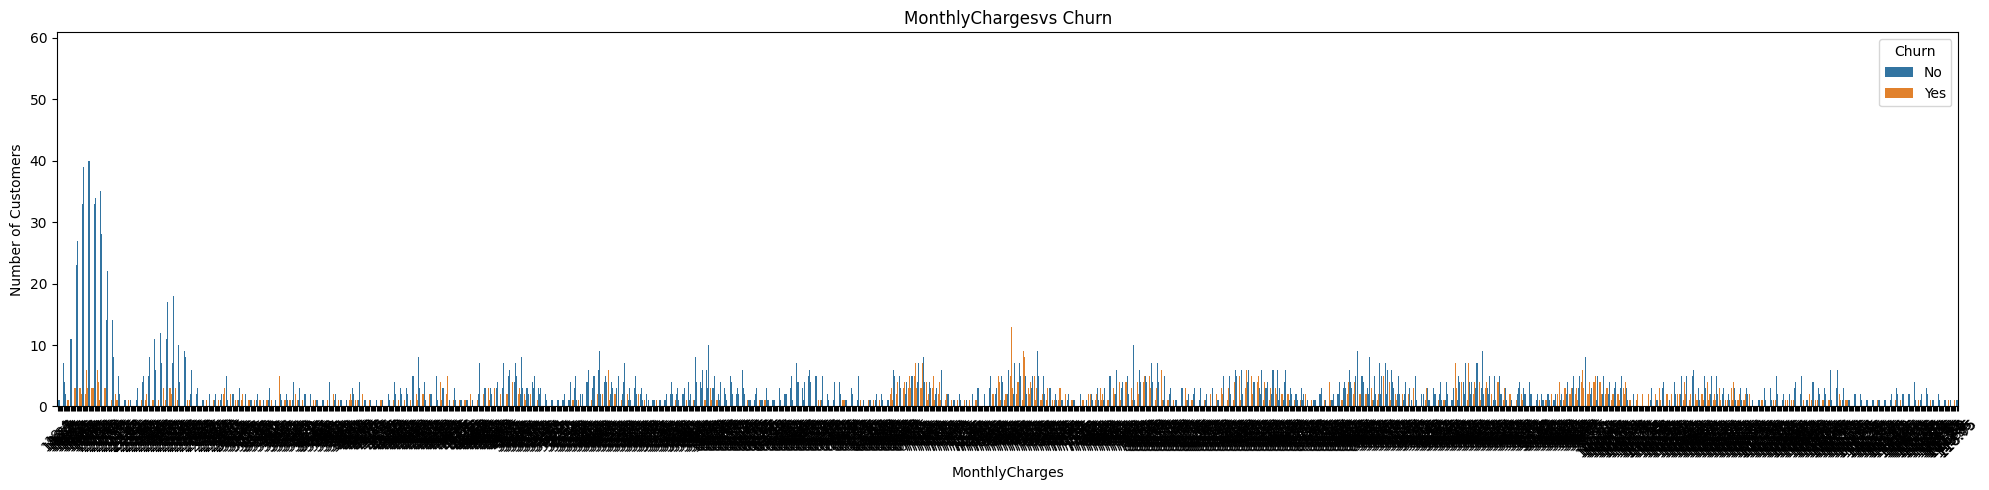

In [ ]:
for feature02 in numerical_features:
  plt.figure(figsize=(20,5))
  sns.countplot(data=data,x=feature02,hue='Churn')
  plt.title(f'{feature02}vs Churn')
  plt.xlabel(feature02)
  plt.ylabel('Number of Customers')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()


### Numerical Data Analysis

The numerical features were analyzed using:

* Distribution plots
* Q-Q plots
* Boxplots
* Comparison with the Churn target

This helped identify the distribution shape, possible skewness, and potential outliers in the numerical variables.

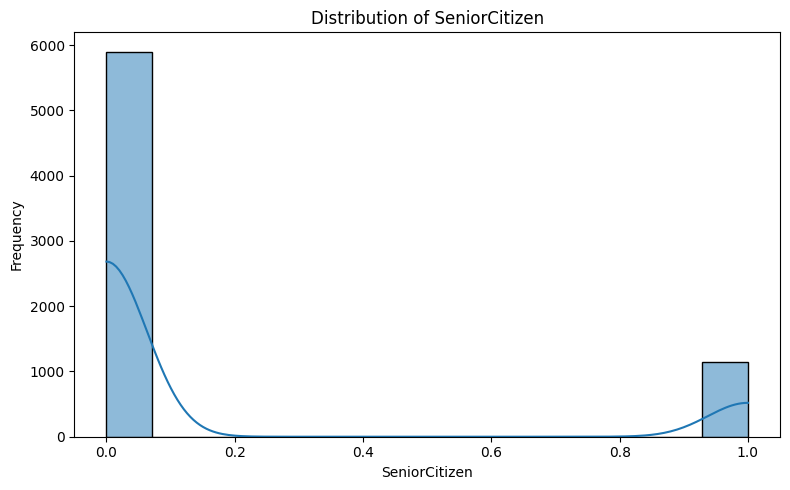

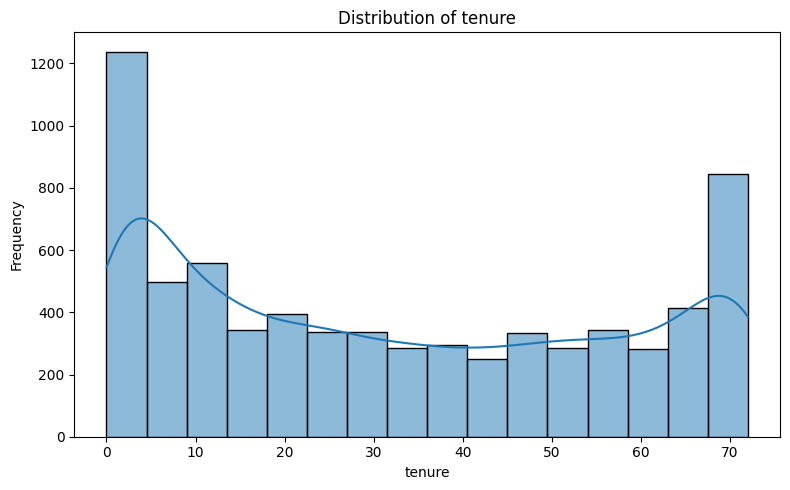

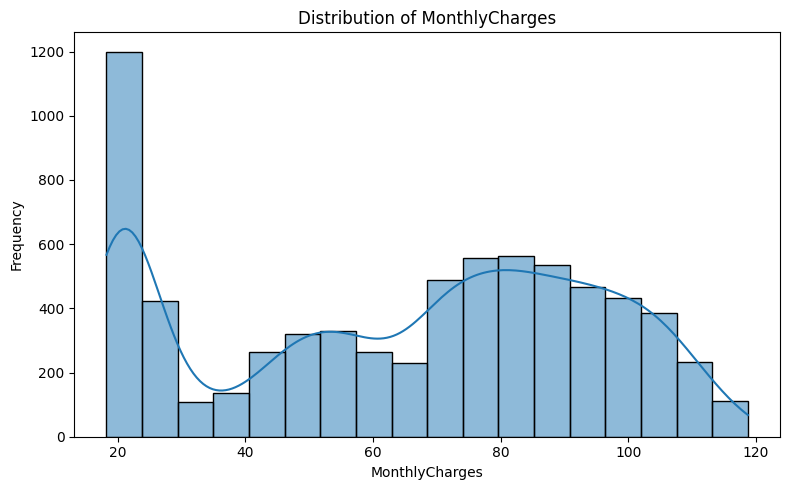

In [ ]:
for feature in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=data,
        x=feature,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

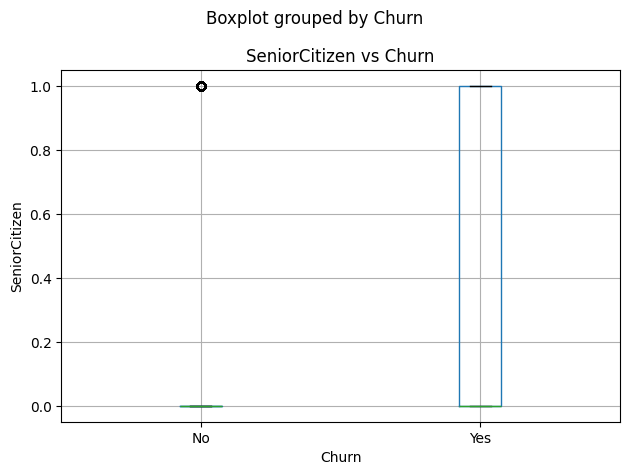

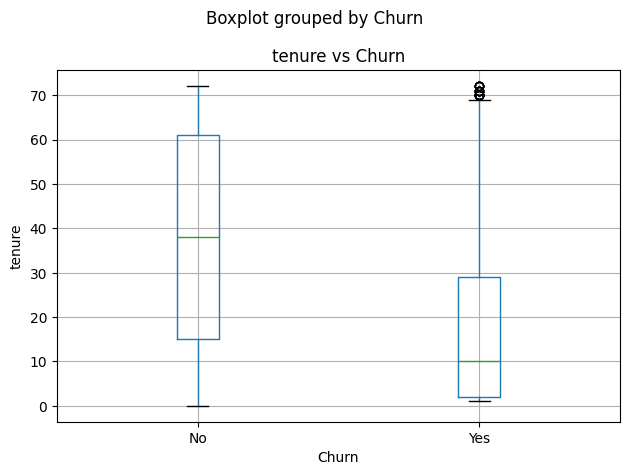

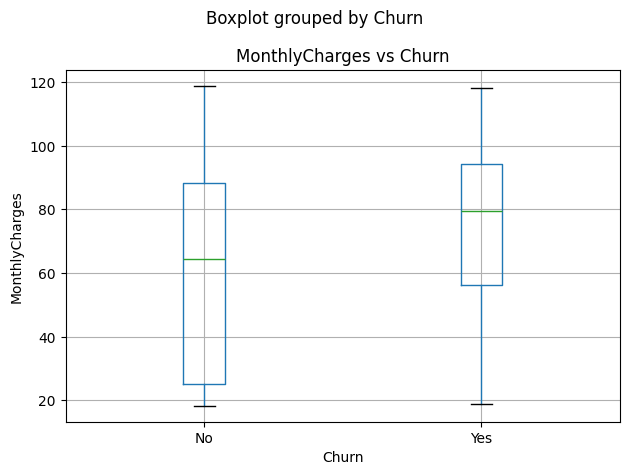

In [ ]:
for feature in numerical_features:
  data.boxplot(column=feature,by='Churn')
  plt.title(f'{feature} vs Churn')
  plt.xlabel('Churn')
  plt.ylabel(feature)
  plt.tight_layout()
  plt.show()

### Conclusion

The EDA indicates that **Contract, Tenure, InternetService, PaymentMethod, TechSupport, OnlineSecurity, OnlineBackup, and DeviceProtection** are among the most informative features for predicting customer churn.

The next stage is **Data Preprocessing**, where the data will be cleaned and transformed into a suitable format for machine learning models.


#Data Preprocessing

In [ ]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [22]:
data.drop(['gender','PhoneService','MultipleLines'],axis=1,inplace=True)

In [23]:
data.head(20)

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,0,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,45,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,No,No,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,0,No,No,8,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,0,No,Yes,22,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,0,No,No,10,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,0,Yes,No,28,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,0,No,Yes,62,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


#Data Type Correction & Missing Value Handling
Identified that TotalCharges was stored as an object instead of a numerical data type.


---


Converted TotalCharges to a numeric type using pd.to_numeric().


---


Invalid or non-numeric values were converted to NaN.
Checked for missing values in TotalCharges.
Removed rows with missing TotalCharges values using dropna().


---



Purpose: Ensure that TotalCharges is properly formatted as a numerical feature before applying preprocessing and machine learning models.

In [24]:
data['TotalCharges']=pd.to_numeric( data['TotalCharges'],errors='coerce')

In [25]:
data['TotalCharges'].isnull().sum()



np.int64(11)

In [26]:
data.dropna(subset=['TotalCharges'])

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,0,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,45,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,No,No,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,Yes,Yes,24,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,0,Yes,Yes,72,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,0,Yes,Yes,11,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,1,Yes,No,4,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


#Binary Categorical Features

Identified the binary categorical features (Partner, Dependents, and PaperlessBilling) that contain only Yes/No values. These features can be encoded as 1/0 during the preprocessing stage. The target variable Churn will also be encoded as 1/0.

In [27]:
binary_features=['Partner', 'Dependents', 'PaperlessBilling','OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',]
for col in binary_features:
  data[col]=data[col].map({'Yes': 1, 'No': 0,'No internet service':0})
data['Churn']=data['Churn'].map({'Yes': 1, 'No': 0})



In [28]:
data.head()


,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,34,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,2,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,45,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,2,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [35]:
print(x_train.columns.tolist())

['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [38]:
y=data['Churn']
x=data.drop('Churn',axis=1)

In [31]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=1
)

In [39]:
print(x_train.columns.tolist())

['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = x_train.select_dtypes(
    include="object"
).columns.tolist()

numerical_features = x_train.select_dtypes(
    include="number"
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [57]:
categorical_features = x_train.select_dtypes(
    include='object'
).columns.tolist()


In [58]:
print(categorical_features)

['InternetService', 'Contract', 'PaymentMethod']


In [59]:
X_train_processed = preprocessor.fit_transform(x_train)

X_test_processed = preprocessor.transform(x_test)

In [44]:
print(x_train.isnull().sum())

SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        8
dtype: int64


In [48]:
data['TotalCharges'] = pd.to_numeric(
    data['TotalCharges'],
    errors='coerce'
)

In [49]:
data['TotalCharges'] = data['TotalCharges'].fillna(
    data['TotalCharges'].median()
)

In [50]:
data.head()

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,0,1,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,34,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,2,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,45,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,2,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [52]:
print("NaN in X_train:")
print(x_train.isna().sum()[x_train.isna().sum() > 0])

print("\nNaN in X_test:")
print(x_test.isna().sum()[x_test.isna().sum() > 0])

NaN in X_train:
TotalCharges    8
dtype: int64

NaN in X_test:
TotalCharges    3
dtype: int64


In [53]:
median_total_charges = x_train["TotalCharges"].median()

x_train["TotalCharges"] = x_train["TotalCharges"].fillna(
    median_total_charges
)

x_test["TotalCharges"] = x_test["TotalCharges"].fillna(
    median_total_charges
)

In [54]:
print("NaN in X_train:")
print(x_train.isna().sum()[x_train.isna().sum() > 0])

print("\nNaN in X_test:")
print(x_test.isna().sum()[x_test.isna().sum() > 0])

NaN in X_train:
Series([], dtype: int64)

NaN in X_test:
Series([], dtype: int64)


In [60]:
from sklearn.linear_model import LogisticRegression

model_1 = LogisticRegression()
model_1.fit(X_train_processed, y_train)

c:\Users\C.M\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [61]:
y_pred_lg = model_1.predict(X_test_processed)

In [62]:
from sklearn.metrics import accuracy_score, classification_report

print("LogisticRegression Accuracy:", accuracy_score(y_test, y_pred_lg))
print(classification_report(y_test,y_pred_lg))

LogisticRegression Accuracy: 0.808374733853797
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1061
           1       0.62      0.57      0.60       348

    accuracy                           0.81      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)

rf_model.fit(X_train_processed , y_train)

y_pred_rf = rf_model.predict(X_test_processed )

In [64]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7927608232789212
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1061
           1       0.59      0.52      0.55       348

    accuracy                           0.79      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.79      0.79      0.79      1409



In [65]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=1
)

gb_model.fit(X_train_processed, y_train)

y_pred_gb = gb_model.predict(X_test_processed)

In [66]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8048261178140526
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1061
           1       0.62      0.55      0.58       348

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



In [72]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 1.9 MB/s eta 0:00:26
    --------------------------------------- 1.0/48.9 MB 1.9 MB/s eta 0:00:25
   - -------------------------------------- 1.3/48.9 MB 1.9 MB/s eta 0:00:25
   - -------------------------------------- 1.8/48.9 MB 1.9 MB/s eta 0:00:25
   - -------------------------------------- 1.8/48.9 MB 1.9 MB/s eta 0:00:25
   - -------------------------------------- 2.1/48.9 MB 1.7 MB/s eta 0:00:28
   -- ------------------------------------- 2.9/48.9 MB 1.9 MB/s eta 0:00:25
   -- ------------------------------------- 3.4/48.9 MB 1.9 MB/s eta 0:00:25
   -- ------------------------------------- 3.4/48.9 MB 1.9 MB/s eta 0:00:25
   --- ------------------------------------ 3.9/48.9 MB 1.8 MB/s eta 0:00:25
   --- ------------------------------------ 4.5/48.9 MB 1.8 MB/s eta 0:00:25
   --- ------

In [73]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_processed, y_train)

y_pred_xgb = xgb_model.predict(X_test_processed)

In [74]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8090844570617459
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1061
           1       0.62      0.57      0.60       348

    accuracy                           0.81      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



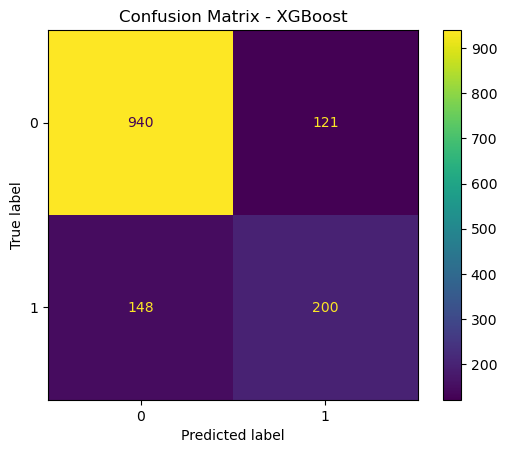

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=xgb_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [78]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [79]:
xgb = XGBClassifier(
    random_state=1,
    eval_metric='logloss'
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [80]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV F1:")
print(grid_search.best_score_)

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1:
0.590123855888262


In [81]:
best_xgb = grid_search.best_estimator_

In [82]:
best_xgb.save_model("best_xgb_model.json")

In [84]:
# ============================================================
# SAVE FINAL CUSTOMER CHURN MODEL ARTIFACTS
# ============================================================

import os
import json
import joblib
import numpy as np


# ============================================================
# 1. Create folder for saved model files
# ============================================================

ARTIFACTS_DIR = "artifacts"

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print("=" * 60)
print("Saving Customer Churn Model Artifacts")
print("=" * 60)


# ============================================================
# 2. Save XGBoost model
# ============================================================

MODEL_PATH = os.path.join(
    ARTIFACTS_DIR,
    "best_xgb_model.json"
)

xgb_model.save_model(MODEL_PATH)

print(f"✅ XGBoost model saved:")
print(f"   {MODEL_PATH}")


# ============================================================
# 3. Save preprocessing object
# ============================================================

PREPROCESSOR_PATH = os.path.join(
    ARTIFACTS_DIR,
    "preprocessor.pkl"
)

joblib.dump(
    preprocessor,
    PREPROCESSOR_PATH
)

print(f"✅ Preprocessor saved:")
print(f"   {PREPROCESSOR_PATH}")


# ============================================================
# 4. Save feature information
# ============================================================

FEATURE_INFO_PATH = os.path.join(
    ARTIFACTS_DIR,
    "feature_info.json"
)


# Get original input features
input_features = x_train.columns.tolist()


# Get categorical features
categorical_features = x_train.select_dtypes(
    include="object"
).columns.tolist()


# Get numerical features
numerical_features = x_train.select_dtypes(
    include=np.number
).columns.tolist()


# Get final features after preprocessing
processed_features = (
    preprocessor.get_feature_names_out().tolist()
)


feature_info = {

    "target_column": "Churn",

    "target_classes": {
        "No": 0,
        "Yes": 1
    },

    "input_features": input_features,

    "categorical_features": categorical_features,

    "numerical_features": numerical_features,

    "processed_features": processed_features,

    "number_of_input_features": len(
        input_features
    ),

    "number_of_processed_features": len(
        processed_features
    )
}


with open(
    FEATURE_INFO_PATH,
    "w"
) as file:

    json.dump(
        feature_info,
        file,
        indent=4
    )


print(f"✅ Feature information saved:")
print(f"   {FEATURE_INFO_PATH}")


# ============================================================
# 5. Save model information
# ============================================================

MODEL_INFO_PATH = os.path.join(
    ARTIFACTS_DIR,
    "model_info.json"
)


model_info = {

    "model_type": "XGBClassifier",

    "model_file": "best_xgb_model.json",

    "preprocessor_file": "preprocessor.pkl",

    "feature_info_file": "feature_info.json",

    "target": "Churn",

    "prediction_type": "binary_classification",

    "classes": {
        "0": "No Churn",
        "1": "Churn"
    }
}


with open(
    MODEL_INFO_PATH,
    "w"
) as file:

    json.dump(
        model_info,
        file,
        indent=4
    )


print(f"✅ Model information saved:")
print(f"   {MODEL_INFO_PATH}")


# ============================================================
# 6. Verify saved files
# ============================================================

print("\n" + "=" * 60)
print("VERIFYING SAVED FILES")
print("=" * 60)


files_to_check = [

    MODEL_PATH,

    PREPROCESSOR_PATH,

    FEATURE_INFO_PATH,

    MODEL_INFO_PATH

]


all_files_exist = True


for file_path in files_to_check:

    if os.path.exists(file_path):

        size = os.path.getsize(file_path)

        print(
            f"✅ {os.path.basename(file_path)}"
            f" → موجود | Size: {size:,} bytes"
        )

    else:

        print(
            f"❌ {os.path.basename(file_path)}"
            f" → NOT FOUND"
        )

        all_files_exist = False


# ============================================================
# 7. Final result
# ============================================================

print("\n" + "=" * 60)

if all_files_exist:

    print(
        "🎉 ALL MODEL FILES SAVED SUCCESSFULLY!"
    )

    print("\nFolder:")
    print(
        os.path.abspath(ARTIFACTS_DIR)
    )

else:

    print(
        "⚠️ Some files were not saved correctly."
    )

print("=" * 60)

Saving Customer Churn Model Artifacts
✅ XGBoost model saved:
   artifacts\best_xgb_model.json
✅ Preprocessor saved:
   artifacts\preprocessor.pkl
✅ Feature information saved:
   artifacts\feature_info.json
✅ Model information saved:
   artifacts\model_info.json

VERIFYING SAVED FILES
✅ best_xgb_model.json → موجود | Size: 302,742 bytes
✅ preprocessor.pkl → موجود | Size: 3,431 bytes
✅ feature_info.json → موجود | Size: 2,027 bytes
✅ model_info.json → موجود | Size: 321 bytes

🎉 ALL MODEL FILES SAVED SUCCESSFULLY!

Folder:
c:\Users\C.M\Downloads\customer_churn_prediction\artifacts


In [ ]:
preprocessor

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical_encoding',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['InternetService', 'Contract',
                                  'PaymentMethod', 'TotalCharges'])])

In [ ]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [ ]:
import json

feature_info = {
    "categorical_features": categorical_features.tolist()
        if hasattr(categorical_features, "tolist")
        else list(categorical_features),

    "numerical_features": numerical_features.tolist()
        if hasattr(numerical_features, "tolist")
        else list(numerical_features)
}

with open("feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=4)

In [ ]:
import os

files = [
    "best_xgb_model.json",
    "preprocessor.pkl",
    "feature_info.json"
]

print("Checking saved files...")
print("=" * 40)

for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file)
        print(f"✅ {file}  → موجود | Size: {size} bytes")
    else:
        print(f"❌ {file}  → غير موجود")

Checking saved files...
✅ best_xgb_model.json  → موجود | Size: 357845 bytes
✅ preprocessor.pkl  → موجود | Size: 45850 bytes
✅ feature_info.json  → موجود | Size: 213 bytes


In [1]:
from xgboost import XGBClassifier
import joblib
import json

# Load model
loaded_model = XGBClassifier()
loaded_model.load_model("best_xgb_model.json")

# Load preprocessor
loaded_preprocessor = joblib.load("preprocessor.pkl")

# Load feature information
with open("feature_info.json", "r") as f:
    loaded_feature_info = json.load(f)

print("✅ Model loaded")
print("✅ Preprocessor loaded")
print("✅ Feature information loaded")

print("\nFeature information:")
print(loaded_feature_info)

XGBoostError: [10:47:14] /__w/xgboost/xgboost/src/common/io.cc:144: Opening best_xgb_model.json failed: No such file or directory
Stack trace:
  [bt] (0) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(+0x21ec5c) [0x7f5e8d41ec5c]
  [bt] (1) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(+0x33cb83) [0x7f5e8d53cb83]
  [bt] (2) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(+0x133de7) [0x7f5e8d333de7]
  [bt] (3) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(XGBoosterLoadModel+0xbe) [0x7f5e8d33421e]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7f5ecdd54e2e]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7f5ecdd51493]
  [bt] (6) /usr/lib/python3.13/lib-dynload/_ctypes.cpython-313-x86_64-linux-gnu.so(+0x15534) [0x7f5ecdb78534]
  [bt] (7) /usr/lib/python3.13/lib-dynload/_ctypes.cpython-313-x86_64-linux-gnu.so(+0x1522b) [0x7f5ecdb7822b]
  [bt] (8) /usr/bin/python3(_PyObject_MakeTpCall+0x304) [0x5917c4]

